# PVLive PV capacity by GSP region

This notebook retrieves the latest estimated photovoltaic capacity for each GSP region from the Sheffield Solar PVLive API v4. It joins the API values to the reusable GSP GeoJSON exported from `02_GSP_regions.ipynb`.

The active metric is `capacity_mwp`, which represents estimated effective PV capacity. To use raw installed capacity instead, change `CAPACITY_FIELD` to `installedcapacity_mwp` in the configuration cell.

- Source: https://www.solar.sheffield.ac.uk/api/

In [1]:
from pathlib import Path
import time

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests

API_BASE_URL = "https://api.pvlive.uk/pvlive/api/v4"
CAPACITY_FIELD = "capacity_mwp"
# CAPACITY_FIELD = "installedcapacity_mwp"

REFERENCE_DATA_PATH = Path("../data/outputs/reference_data")
GSP_PATH = REFERENCE_DATA_PATH / "gsp_regions_with_colour_and_ghi_coverage.geojson"
OUTPUT_GEOJSON = REFERENCE_DATA_PATH / "gsp_regions_with_pvlive_capacity.geojson"
OUTPUT_CSV = REFERENCE_DATA_PATH / "gsp_regions_with_pvlive_capacity.csv"

gsp_regions = gpd.read_file(GSP_PATH)
print(f"Loaded {len(gsp_regions)} GSP regions from {GSP_PATH}")

Loaded 362 GSP regions from ..\data\outputs\reference_data\gsp_regions_with_colour_and_ghi_coverage.geojson


## Retrieve the PVLive GSP lookup

The API returns a `meta` list containing column names and a `data` list containing row arrays. The national aggregate (`gsp_id=0`) is excluded because this notebook works at GSP-region level.

In [2]:
def get_pvlive_table(endpoint, params=None):
    response = requests.get(
        f"{API_BASE_URL}/{endpoint}",
        params=params,
        timeout=30,
    )
    response.raise_for_status()
    payload = response.json()
    return pd.DataFrame(payload.get("data", []), columns=payload.get("meta", []))

gsp_lookup = get_pvlive_table("gsp_list")
gsp_lookup = gsp_lookup[gsp_lookup["gsp_id"] != 0].copy()
gsp_lookup["gsp_id"] = gsp_lookup["gsp_id"].astype(int)

print(f"PVLive GSP records retrieved: {len(gsp_lookup)}")
gsp_lookup.head()

PVLive GSP records retrieved: 334


,gsp_id,gsp_name,pes_id
1,1,ABHA1,22
2,2,ABNE_P,17
3,3,ABTH_1,21
4,6,ALNE_P,17
5,7,ALST_3|USKM_1,21


## Retrieve the latest capacity record for each GSP

No date range is supplied. Each endpoint therefore returns the latest available record, including the selected capacity field.

In [9]:
capacity_records = []
failed_gsp_ids = []
total_gsp_requests = len(gsp_lookup)
progress_interval = 25

print(f"Starting PVLive requests for {total_gsp_requests} GSPs...", flush=True)

for request_number, gsp_id in enumerate(gsp_lookup["gsp_id"], start=1):
    try:
        gsp_record = get_pvlive_table(
            f"gsp/{gsp_id}",
            params={"extra_fields": CAPACITY_FIELD},
        )
        if not gsp_record.empty:
            record = gsp_record.iloc[-1].to_dict()
            record["gsp_id"] = int(gsp_id)
            capacity_records.append(record)
    except requests.RequestException as error:
        failed_gsp_ids.append({"gsp_id": int(gsp_id), "error": str(error)})
    time.sleep(0.05)

    if request_number % progress_interval == 0 or request_number == total_gsp_requests:
        percentage = request_number / total_gsp_requests * 100
        print(
            f"Progress: {request_number}/{total_gsp_requests} GSPs "
            f"({percentage:.1f}%) processed; current gsp_id={gsp_id}",
            flush=True,
        )

pvlive_capacity = pd.DataFrame(capacity_records)
if CAPACITY_FIELD not in pvlive_capacity:
    pvlive_capacity[CAPACITY_FIELD] = pd.NA
pvlive_capacity[CAPACITY_FIELD] = pd.to_numeric(
    pvlive_capacity[CAPACITY_FIELD],
    errors="coerce",
)

print(f"Capacity records retrieved: {len(pvlive_capacity)}")
print(f"Failed GSP requests: {len(failed_gsp_ids)}")
pvlive_capacity.head()

Starting PVLive requests for 334 GSPs...
Progress: 25/334 GSPs (7.5%) processed; current gsp_id=28
Progress: 50/334 GSPs (15.0%) processed; current gsp_id=55
Progress: 75/334 GSPs (22.5%) processed; current gsp_id=82
Progress: 100/334 GSPs (29.9%) processed; current gsp_id=107
Progress: 125/334 GSPs (37.4%) processed; current gsp_id=133
Progress: 150/334 GSPs (44.9%) processed; current gsp_id=164
Progress: 175/334 GSPs (52.4%) processed; current gsp_id=189
Progress: 200/334 GSPs (59.9%) processed; current gsp_id=214
Progress: 225/334 GSPs (67.4%) processed; current gsp_id=240
Progress: 250/334 GSPs (74.9%) processed; current gsp_id=266
Progress: 275/334 GSPs (82.3%) processed; current gsp_id=291
Progress: 300/334 GSPs (89.8%) processed; current gsp_id=317
Progress: 325/334 GSPs (97.3%) processed; current gsp_id=342
Progress: 334/334 GSPs (100.0%) processed; current gsp_id=351
Capacity records retrieved: 334
Failed GSP requests: 0


,gsp_id,datetime_gmt,generation_mw,capacity_mwp
0,1,2026-09-22T09:30:00Z,21.403,229.139
1,2,2026-09-22T09:30:00Z,9.517,30.081
2,3,2026-09-22T09:30:00Z,15.361,106.322
3,6,2026-09-22T09:30:00Z,1.952,5.645
4,7,2026-09-22T09:30:00Z,43.365,191.812


## Join PVLive capacity to the GSP regions

The source GSP GeoJSON contains NESO names in the `GSPs` field, so it is first matched to the PVLive lookup to obtain `gsp_id`. The capacity data are then joined using `gsp_id`.

In [5]:
gsp_with_ids = gsp_regions.merge(
    gsp_lookup[["gsp_id", "gsp_name"]],
    left_on="GSPs",
    right_on="gsp_name",
    how="left",
)

gsp_with_capacity = gsp_with_ids.merge(
    pvlive_capacity[["gsp_id", "datetime_gmt", CAPACITY_FIELD]],
    on="gsp_id",
    how="left",
    validate="many_to_one",
)

unmatched_regions = gsp_with_capacity["gsp_id"].isna().sum()
missing_capacity = gsp_with_capacity[CAPACITY_FIELD].isna().sum()
print(f"GSP polygons without a PVLive ID match: {unmatched_regions}")
print(f"GSP polygons without a capacity value: {missing_capacity}")
gsp_with_capacity[["GSPs", "gsp_id", CAPACITY_FIELD]].head()

GSP polygons without a PVLive ID match: 5
GSP polygons without a capacity value: 5


,GSPs,gsp_id,capacity_mwp
0,LEGA_1,182.0,230.344
1,THSO_P,288.0,5.545
2,BRIM_1,40.0,40.394
3,EERH,104.0,12.055
4,AXMI1,13.0,122.091


In [6]:
gsp_with_capacity[[CAPACITY_FIELD]].describe()

,capacity_mwp
count,357.000000
mean,73.268885
std,123.277122
min,0.000000
25%,4.759000
50%,14.870000
75%,81.347000
max,659.724000


## Map PVLive capacity by GSP region

I want the exactly-zero (capacity) regions to be a different colour than small positive values. There are also a couple of small regions with NaN data but I don't really think I care much about those; I think I can treat them as zeroes tbh since the data is so comprehensive (at least it is rn)

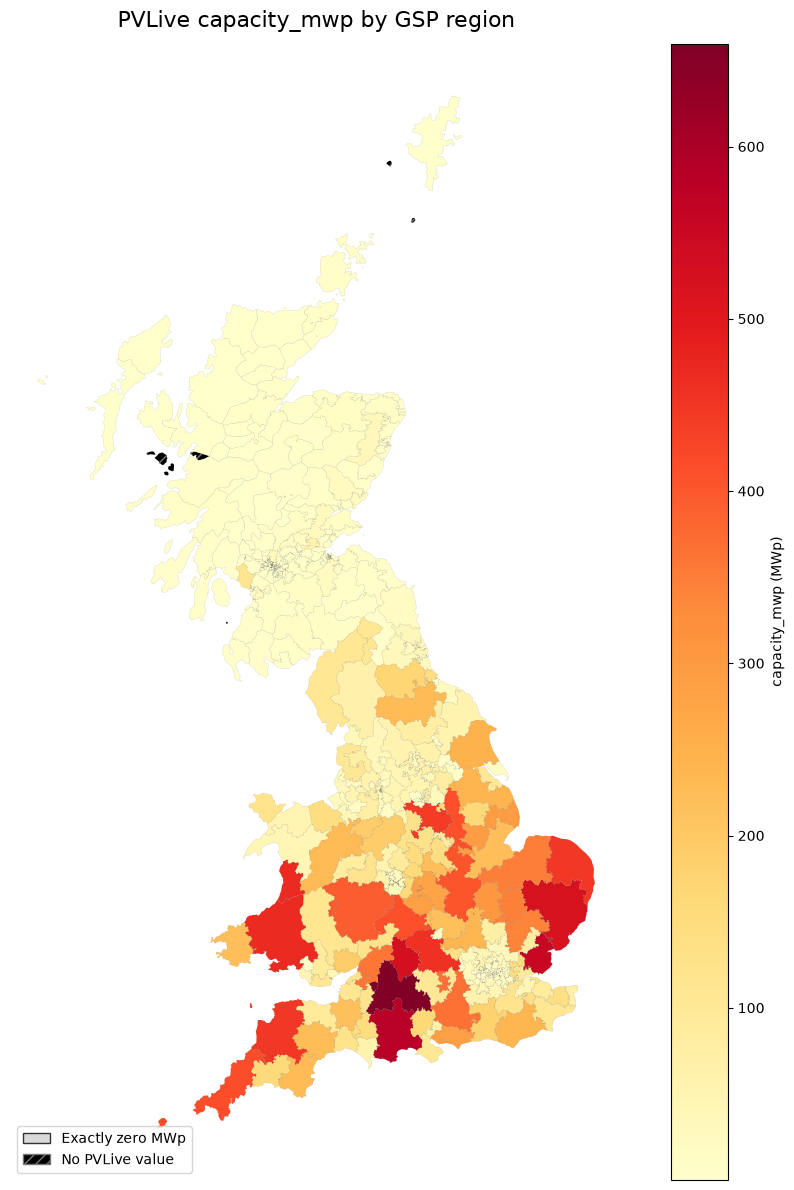

In [13]:
from matplotlib.patches import Patch

missing_regions = gsp_with_capacity[gsp_with_capacity[CAPACITY_FIELD].isna()]
zero_regions = gsp_with_capacity[gsp_with_capacity[CAPACITY_FIELD] == 0]
positive_regions = gsp_with_capacity[gsp_with_capacity[CAPACITY_FIELD] > 0]

fig, ax = plt.subplots(figsize=(10, 12))

# Plot missing values separately so they are not confused with exact zeros.
missing_regions.plot(
    ax=ax,
    facecolor="black",
    edgecolor="#777777",
    hatch="///",
    linewidth=0.05,
    zorder=1,
)
zero_regions.plot(
    ax=ax,
    facecolor="#d9d9d9",
    edgecolor="#333333",
    linewidth=0.05,
    zorder=2,
)

if not positive_regions.empty:
    positive_regions.plot(
        ax=ax,
        column=CAPACITY_FIELD,
        cmap="YlOrRd",
        vmin=positive_regions[CAPACITY_FIELD].min(),
        vmax=positive_regions[CAPACITY_FIELD].max(),
        edgecolor="#333333",
        linewidth=0.05,
        legend=True,
        legend_kwds={"label": f"{CAPACITY_FIELD} (MWp)"},
        zorder=3,
    )

ax.set_title(f"PVLive {CAPACITY_FIELD} by GSP region", fontsize=16, pad=12)
ax.legend(
    handles=[
        Patch(
            facecolor="#d9d9d9",
            edgecolor="#333333",
            label="Exactly zero MWp",
        ),
        Patch(
            facecolor="black",
            edgecolor="#777777",
            hatch="///",
            label="No PVLive value",
        ),
    ],
    loc="lower left",
    frameon=True,
)
ax.set_axis_off()
fig.tight_layout()
plt.show()

In [8]:
OUTPUT_GEOJSON.parent.mkdir(parents=True, exist_ok=True)
gsp_with_capacity.to_file(OUTPUT_GEOJSON, driver="GeoJSON")
gsp_with_capacity.drop(columns="geometry").to_csv(OUTPUT_CSV, index=False)

print(f"Saved joined GeoJSON to: {OUTPUT_GEOJSON}")
print(f"Saved joined CSV to: {OUTPUT_CSV}")

Saved joined GeoJSON to: ..\data\outputs\reference_data\gsp_regions_with_pvlive_capacity.geojson
Saved joined CSV to: ..\data\outputs\reference_data\gsp_regions_with_pvlive_capacity.csv


Would be useful to ensure if any PV_Live-given capacity data is being lost due to the code's inability to match it to its corresponding geographical data:

In [10]:
from difflib import get_close_matches

# Investigate GSP polygons that did not match a PVLive GSP name.
unmatched_gsps = gsp_with_capacity[gsp_with_capacity["gsp_id"].isna()].copy()

# Area is calculated in British National Grid metres, then reported in km2.
unmatched_gsps["area_km2"] = unmatched_gsps.to_crs("EPSG:27700").geometry.area / 1_000_000
pvlive_names = gsp_lookup["gsp_name"].tolist()
unmatched_gsps["closest_pvlive_names"] = unmatched_gsps["GSPs"].map(
    lambda name: ", ".join(get_close_matches(name, pvlive_names, n=3, cutoff=0.35))
)

print("Unmatched GSP polygons:")
print(
    unmatched_gsps[["GSPs", "GSPGroup", "area_km2", "closest_pvlive_names"]]
    .sort_values("area_km2", ascending=False)
    .to_string(index=False)
)

print("\nLargest matched GSP capacities:")
print(
    gsp_with_capacity[["GSPs", "gsp_id", CAPACITY_FIELD]]
    .dropna(subset=[CAPACITY_FIELD])
    .drop_duplicates("gsp_id")
    .sort_values(CAPACITY_FIELD, ascending=False)
    .head(15)
    .to_string(index=False)
)

print("\nLargest unmatched polygon area (km2):")
print(unmatched_gsps["area_km2"].max())

Unmatched GSP polygons:
                GSPs GSPGroup   area_km2 closest_pvlive_names
Off_NETS(unassigned)      NaN 220.672441                     
Off_NETS(unassigned)      NaN 110.519324                     
Off_NETS(unassigned)      NaN  23.479842                     
Off_NETS(unassigned)      NaN  17.113305                     
Off_NETS(unassigned)      NaN   3.616260                     

Largest matched GSP capacities:
        GSPs  gsp_id  capacity_mwp
      MELK_1   199.0       659.724
      MANN_1   197.0       580.312
      RAYL_1   245.0       552.760
      MITY_1   202.0       528.169
BRFO_1|CLT03    38.0       518.783
      SWAN_1   281.0       467.257
      COWL_1   324.0       457.218
NORM_1|SALL1   214.0       447.533
       ALVE1     8.0       447.493
      CHTE_1    66.0       441.429
       INDQ1   152.0       414.657
      FECK_6   117.0       412.146
      STAY_1   274.0       411.521
      GREN_1   135.0       402.420
      BISW_1    26.0       393.900

Largest un

In [11]:
# Confirm that no successful PVLive capacity record is discarded for lack of geometry.
geo_gsp_ids = set(gsp_with_capacity["gsp_id"].dropna().astype(int))
pvlive_gsp_ids = set(pvlive_capacity["gsp_id"].astype(int))
pvlive_without_geometry = pvlive_capacity[
    ~pvlive_capacity["gsp_id"].isin(geo_gsp_ids)
].copy()

print(f"PVLive GSP capacity records retrieved: {len(pvlive_capacity)}")
print(f"PVLive GSP IDs represented geographically: {len(pvlive_gsp_ids & geo_gsp_ids)}")
print(f"PVLive capacity records without geometry: {len(pvlive_without_geometry)}")

if not pvlive_without_geometry.empty:
    print(pvlive_without_geometry[["gsp_id", CAPACITY_FIELD]].to_string(index=False))
else:
    print("All successful PVLive capacity records have a corresponding GSP geometry.")

assert pvlive_without_geometry.empty

PVLive GSP capacity records retrieved: 334
PVLive GSP IDs represented geographically: 334
PVLive capacity records without geometry: 0
All successful PVLive capacity records have a corresponding GSP geometry.
